## PyTorch Grad-CAM Heatmap & Convolution Layer 해석 예제

PyTorch의 **Hook**과 **Autograd**를 이용하면 CNN 내부의 **Feature Map(활성값)** 과 **Gradient** 를 추출할 수 있다.
대표적인 CNN 모델 해석(Interpretability) 방법은 다음과 같다.

| 방법 | 설명 |
|------|------|
| Feature Map Visualization | 특정 Conv 레이어 출력 채널을 이미지처럼 시각화 |
| CAM (Class Activation Mapping) | Global Average Pooling 직전 feature에 FC 가중치를 곱해 클래스별 영역 강조 |
| **Grad-CAM** | 목표 클래스 score에 대한 feature map **gradient**로 채널 가중치를 구하고 heatmap 생성 |
| Attention Visualization | Transformer self-attention map 시각화 (ViT 등) |

이 노트북에서는 가장 널리 쓰이는 **Grad-CAM** 을 중심으로, **Conv2d 레이어에 Hook을 등록**하는 통합 구현을 다룬다.

**Grad-CAM 요약**

Gradient-weighted Class Activation Mapping

마지막(또는 지정) Conv 레이어의 feature map $A^k$ 와 gradient $\frac{\partial y^c}{\partial A^k}$ 로 채널 가중치 $\alpha_k^c$ 를 구한다.

$$\alpha_k^c = \frac{1}{Z}\sum_i\sum_j \frac{\partial y^c}{\partial A_{ij}^k}$$

$$L^c = \mathrm{ReLU}\left(\sum_k \alpha_k^c A^k\right)$$

위 heatmap $L^c$ 를 원본 이미지 크기로 업샘플하여 overlay 한다.

| 섹션 | 내용 |
|------|------|
| 1 | 환경 설정 |
| 2 | Hook 기반 Feature / Gradient 추출 유틸 |
| 3 | Conv 레이어가 분리된 MNIST CNN |
| 4 | Feature Map 시각화 |
| 5 | Grad-CAM Heatmap |
| 6 | (선택) 사전학습 ResNet18 + ImageNet 샘플 |

### 1. 환경 설정

In [1]:
# ========== Library import ==========
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
from torchvision.utils import make_grid  # feature map 채널을 grid 이미지로 묶을 때 사용
import matplotlib.pyplot as plt

# GPU가 있으면 cuda, 없으면 cpu (이후 모든 텐서·모델 이동 기준)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch:', torch.__version__)
print('Device:', device)


PyTorch: 2.11.0+cu126
Device: cuda


### 2. Convolution Hook + Grad-CAM 유틸

- **forward hook**: Conv 출력(feature map) 저장
- **backward hook** (`register_full_backward_hook`): 해당 feature에 대한 gradient 저장
- `target_layer`에는 `nn.Conv2d` 모듈(또는 그 출력을보내는 블록)을 지정한다.

In [2]:
# =============================================================================
# Hook + Grad-CAM 유틸리티
# - Forward hook  : Conv 레이어 "출력"(activation / feature map) 저장
# - Backward hook : 해당 출력에 대한 gradient 저장 (Autograd 역전파 시)
# =============================================================================


class ConvActivationGradient:
    """
    단일 nn.Conv2d(또는 Conv 출력을보내는 모듈)에 hook을 등록해
    forward 시 activations, backward 시 gradients 를 메모리에 보관한다.

    Grad-CAM / Feature Map 시각화의 공통 기반 클래스.
    """

    def __init__(self, target_layer: nn.Module):
        self.target_layer = target_layer
        self.activations = None  # forward 직후 채워짐: shape (N, C, H, W)
        self.gradients = None    # backward 직후 채워짐: shape (N, C, H, W)

        # PyTorch가 해당 레이어를 지날 때마다 콜백 호출
        self._fwd_handle = target_layer.register_forward_hook(self._forward_hook)
        # full_backward_hook: grad_output이 tuple로 전달됨 (첫 원소가 dL/d(activation))
        self._bwd_handle = target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, inputs, output):
        # output: Conv 직후 텐서. detach()로 그래프에 붙지 않게 저장 (시각화·CAM 계산용)
        self.activations = output.detach()

    def _backward_hook(self, module, grad_input, grad_output):
        # grad_output[0]: loss가 Conv 출력에 미치는 gradient (dL/dA), shape (N, C, H, W)
        self.gradients = grad_output[0].detach()

    def release(self):
        """노트북 셀 재실행 시 hook 중복 등록을 막기 위해 반드시 해제."""
        self._fwd_handle.remove()
        self._bwd_handle.remove()


class GradCAM:
    """
    Grad-CAM (Gradient-weighted Class Activation Mapping)

    처리 순서:
      1. forward  : target Conv 출력 A(feature map)를 forward hook으로 저장
      2. backward : 관심 클래스 logit 1개만 역전파, dA를 backward hook으로 저장
      3. 가중치   : 채널 k마다 alpha_k = spatial_mean(dA^k)
      4. heatmap  : L = ReLU(sum_k alpha_k * A^k), 이후 0~1 min-max 정규화
    """

    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model
        self.collector = ConvActivationGradient(target_layer)

    def __call__(self, x: torch.Tensor, class_idx: int | None = None):
        # 이전 backward 잔여 gradient 제거
        self.model.zero_grad(set_to_none=True)
        x = x.to(next(self.model.parameters()).device)

        # --- Forward: 분류 logit 계산 (이때 target Conv의 activation이 hook에 저장됨) ---
        logits = self.model(x)

        # class_idx 미지정 시 argmax 클래스에 대한 CAM (가장 흔한 사용법)
        if class_idx is None:
            class_idx = int(logits.argmax(dim=1).item())

        # --- Backward: 선택 클래스 score 하나만 역전파 ---
        # retain_graph=False: 단일 이미지·단일 backward이므로 그래프 유지 불필요
        score = logits[0, class_idx]
        score.backward(retain_graph=False)

        # 배치 0번 샘플만 사용 → (C, H, W)
        acts = self.collector.activations[0]
        grads = self.collector.gradients[0]

        # Grad-CAM: 채널 k별 gradient 공간 평균 -> alpha_k (가중치)
        weights = grads.mean(dim=(1, 2))

        # 가중 합으로 2D saliency map 생성 후 음수 제거 (관심 영역만 강조)
        cam = (weights[:, None, None] * acts).sum(dim=0)
        cam = F.relu(cam)

        # 시각화용 min-max 정규화 [0, 1]
        cam = cam.cpu().numpy()
        cam -= cam.min()
        cam /= cam.max() + 1e-8
        return cam, class_idx, logits.detach().cpu()

    def release(self):
        self.collector.release()


def find_last_conv(module: nn.Module) -> nn.Conv2d:
    """
    모델 전체를 순회하며 마지막 Conv2d 반환.
    Grad-CAM은 보통 '분류기 직전' conv에 적용 (고수준 semantic feature).
    """
    last_conv = None
    for m in module.modules():
        if isinstance(m, nn.Conv2d):
            last_conv = m
    if last_conv is None:
        raise ValueError('Conv2d 레이어를 찾을 수 없습니다.')
    return last_conv


def overlay_heatmap(rgb_or_gray, heatmap, alpha=0.45, cmap='jet'):
    """
    원본 이미지와 Grad-CAM heatmap을 알파 블렌딩.

    heatmap은 Conv feature 크기이므로 cv2.resize로 원본 (H, W)에 맞춘다.
    """
    import cv2

    # MNIST처럼 1채널이면 RGB 3채널로 복제
    if rgb_or_gray.ndim == 2:
        base = np.stack([rgb_or_gray] * 3, axis=-1)
    else:
        base = rgb_or_gray.copy()
    if base.max() <= 1.0:
        base = (base * 255).astype(np.uint8)

    h, w = base.shape[:2]
    heat_resized = cv2.resize(heatmap, (w, h))
    colored = cv2.applyColorMap(np.uint8(255 * heat_resized), cv2.COLORMAP_JET)
    colored = cv2.cvtColor(colored, cv2.COLOR_BGR2RGB)
    blended = (alpha * colored + (1 - alpha) * base).astype(np.uint8)
    return blended, heat_resized


def plot_feature_maps(tensor_4d, max_channels=16, title='Feature maps'):
    """
    Feature Map Visualization: Conv 출력 채널 중 일부를 grid로 표시.

    각 채널은 서로 다른 필터 응답(에지, 텍스처 등)을 나타낸다.
    """
    if tensor_4d.dim() == 4:
        tensor_4d = tensor_4d[0]
    c = min(tensor_4d.shape[0], max_channels)
    maps = tensor_4d[:c]
    if maps.dim() == 2:
        maps = maps.unsqueeze(0).unsqueeze(0)
    elif maps.dim() == 3:
        maps = maps.unsqueeze(1)  # (N, 1, H, W) — 3D를 넣으면 make_grid가 RGB 1장으로 해석함
    # 채널별 스케일이 다르므로 공간 축(H, W) 기준 min-max 정규화
    maps = maps - maps.amin(dim=(2, 3), keepdim=True)
    maps = maps / (maps.amax(dim=(2, 3), keepdim=True) + 1e-8)
    grid = make_grid(maps, nrow=int(np.ceil(np.sqrt(c))))
    # grid는 (C, H, W); imshow는 2D(H, W) 또는 HWC만 허용 — CHW는 오류
    img = grid[0].detach().cpu().numpy()
    plt.figure(figsize=(6, 6))
    plt.imshow(img, cmap='viridis')
    plt.title(title)
    plt.axis('off')
    plt.show()


### 3. MNIST CNN — Convolution 블록과 분류기 분리

`features` 안의 **마지막 Conv2d** (`conv3`)에 Hook을 걸어 Grad-CAM을 계산한다.

In [3]:
# =============================================================================
# MNIST용 CNN: Conv 블록(features)과 분류기(classifier) 분리
# → Grad-CAM 타깃 레이어(conv3)를 이름으로 직접 지정 가능
# =============================================================================


class MNISTCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # 28×28 → pool×3 후 3×3 feature map, 128채널
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)   # 28×28
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # 14×14
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1) # 7×7 → Grad-CAM 타깃

        self.features = nn.Sequential(
            self.conv1, nn.ReLU(), nn.MaxPool2d(2),
            self.conv2, nn.ReLU(), nn.MaxPool2d(2),
            self.conv3, nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


# MNIST 표준 정규화 (학습·추론 동일 통계)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_loader = DataLoader(
    datasets.MNIST('./data', train=True, download=True, transform=transform),
    batch_size=128, shuffle=True, num_workers=0,
)
test_loader = DataLoader(
    datasets.MNIST('./data', train=False, download=True, transform=transform),
    batch_size=128, shuffle=False, num_workers=0,
)


In [4]:
def train_one_epoch(model, loader, optimizer, criterion):
    """한 epoch 학습: CrossEntropy + Adam, 배치 평균 loss·accuracy 반환."""
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        n += images.size(0)
    return total_loss / n, correct / n


model = MNISTCNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# 데모용 짧은 학습 (heatmap 품질↑: epoch 3~5 권장)
EPOCHS = 2
for epoch in range(1, EPOCHS + 1):
    loss, acc = train_one_epoch(model, train_loader, optimizer, criterion)
    print(f'Epoch {epoch}/{EPOCHS} | loss={loss:.4f} | train_acc={acc:.4f}')

# Grad-CAM은 추론 모드(eval): Dropout/BatchNorm 동작 고정
model.eval()
print('Target conv layer:', model.conv3)


Epoch 1/2 | loss=0.2185 | train_acc=0.9307
Epoch 2/2 | loss=0.0571 | train_acc=0.9824
Target conv layer: Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))


### 4. Feature Map Visualization (Forward Hook)

입력 한 장에 대해 `conv3` 출력 채널 일부를 시각화한다.

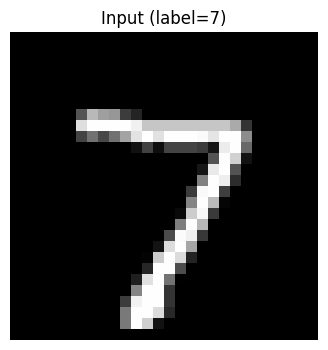

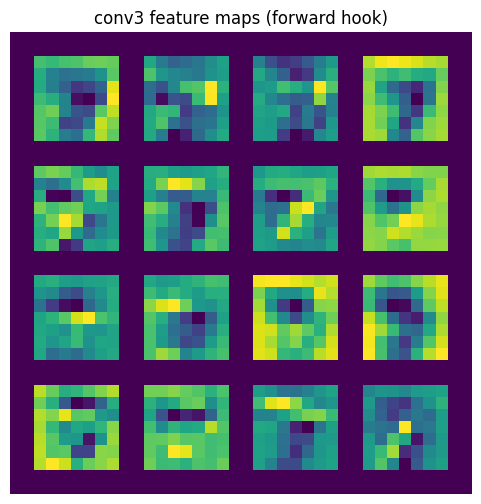

In [5]:
# ========== Feature Map Visualization (Forward Hook만 사용) ==========
# backward 없이 forward 한 번으로 conv3 출력 채널 확인

images, labels = next(iter(test_loader))
img = images[0:1].to(device)  # 배치 차원 유지 (1, 1, 28, 28)
label = int(labels[0].item())

collector = ConvActivationGradient(model.conv3)
with torch.no_grad():
    _ = model(img)  # forward 시 hook이 activations에 feature map 저장

# 화면 표시용: Normalize 역변환 (시각화만, 모델 입력은 정규화된 img 사용)
raw = (images[0, 0].numpy() * 0.3081 + 0.1307).clip(0, 1)
plt.figure(figsize=(4, 4))
plt.imshow(raw, cmap='gray')
plt.title(f'Input (label={label})')
plt.axis('off')
plt.show()

plot_feature_maps(collector.activations, max_channels=16, title='conv3 feature maps (forward hook)')
collector.release()


### 5. Grad-CAM Heatmap (Backward Hook + Autograd)

예측 클래스(또는 지정 클래스) score에 대해 backward한 뒤 heatmap을 생성한다.

True label: 7 | Pred: 7 | prob=1.000


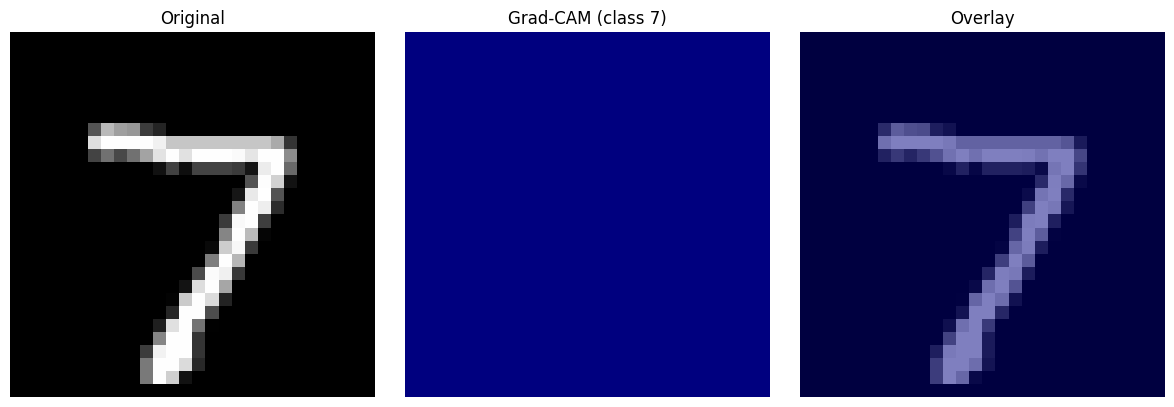

In [6]:
# ========== Grad-CAM Heatmap (Forward + Backward Hook + Autograd) ==========

try:
    import cv2
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'opencv-python-headless'])
    import cv2

# conv3에 hook이 걸린 GradCAM 인스턴스 생성
grad_cam = GradCAM(model, target_layer=model.conv3)
model.eval()

# heatmap: [0,1] numpy (H,W), pred_class: argmax 또는 지정 클래스
heatmap, pred_class, logits = grad_cam(img)
probs = torch.softmax(logits[0], dim=0)
print(f'True label: {label} | Pred: {pred_class} | prob={probs[pred_class]:.3f}')

overlay, _ = overlay_heatmap(raw, heatmap, alpha=0.5)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(raw, cmap='gray')
axes[0].set_title('Original')
axes[1].imshow(heatmap, cmap='jet')
axes[1].set_title(f'Grad-CAM (class {pred_class})')
axes[2].imshow(overlay)
axes[2].set_title('Overlay')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

grad_cam.release()


### 6. (선택) 사전학습 ResNet18 — ImageNet Conv 레이어 Grad-CAM

`torchvision.models.resnet18`의 **layer4** 마지막 Conv 블록에 동일한 `GradCAM` 클래스를 적용한다.

샘플 이미지 로딩 순서: `./data/grad_cam_sample.jpg`(직접 넣은 파일) → PyTorch Hub 예제 URL → **CIFAR-10** (외부 URL 403 등 실패 시 자동 폴백)

ResNet18 pred: 258 (Samoyed), prob=0.878


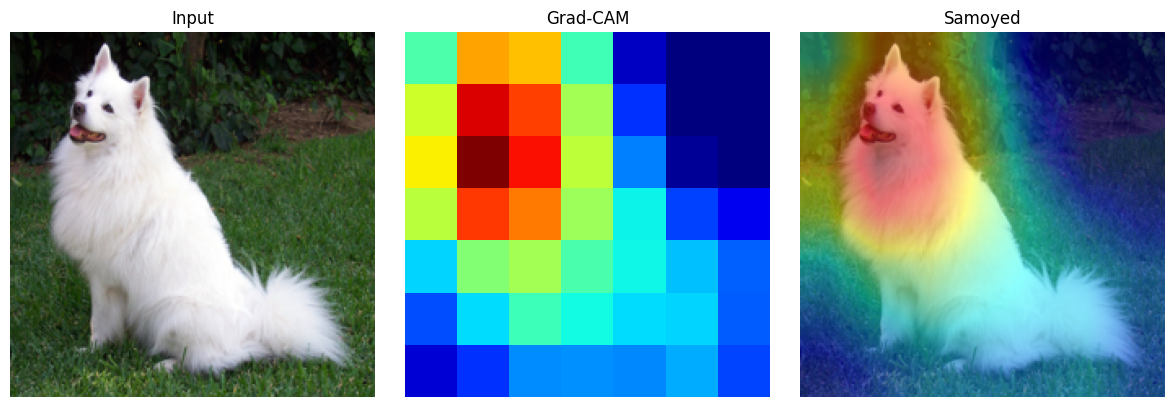

In [ ]:
# =============================================================================
# 사전학습 ResNet18 + ImageNet — 동일 GradCAM을 transfer 모델에 적용
# =============================================================================

from pathlib import Path
from PIL import Image
from torchvision.datasets.utils import download_url


def load_rgb_sample_image(size=224):
    """
    ResNet 입력용 RGB PIL 이미지 (224×224).

    우선순위:
      1) ./data/grad_cam_sample.jpg|.png  사용자 지정
      2) PyTorch Hub dog.jpg 다운로드
      3) CIFAR-10 테스트 샘플 (URL 403·오프라인 시)
    """
    for path in (Path('./data/grad_cam_sample.jpg'), Path('./data/grad_cam_sample.png')):
        if path.is_file():
            print(f'로컬 이미지: {path}')
            return Image.open(path).convert('RGB').resize((size, size))

    hub_path = Path('./data/grad_cam_sample_dog.jpg')
    hub_path.parent.mkdir(parents=True, exist_ok=True)
    if not hub_path.is_file():
        try:
            download_url(
                'https://github.com/pytorch/hub/raw/master/images/dog.jpg',
                str(hub_path.parent),
                filename=hub_path.name,
            )
            print(f'다운로드: {hub_path}')
        except Exception as err:
            print(f'Hub 다운로드 실패 ({err}) → CIFAR-10 폴백')

    if hub_path.is_file():
        return Image.open(hub_path).convert('RGB').resize((size, size))

    cifar = datasets.CIFAR10(root='./data', train=False, download=True)
    pil, label = cifar[7]
    print(f'CIFAR-10 샘플 (class={cifar.classes[label]})')
    return pil.convert('RGB').resize((size, size))


# ImageNet 학습 시 사용한 mean/std (ResNet weights와 쌍)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
imagenet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

weights = models.ResNet18_Weights.IMAGENET1K_V1
resnet = models.resnet18(weights=weights).to(device).eval()

# ResNet BasicBlock: conv1 → bn → relu → conv2 → ... ; layer4 마지막 블록의 conv2가 고수준 feature
target_conv = resnet.layer4[-1].conv2

pil_img = load_rgb_sample_image(224)

# 모델 입력: 정규화된 텐서 / 화면 표시: [0,1] RGB numpy
tensor = imagenet_transform(pil_img).unsqueeze(0).to(device)
display_np = np.array(pil_img.resize((224, 224))) / 255.0

cam_engine = GradCAM(resnet, target_layer=target_conv)
heatmap_rn, pred_rn, logits_rn = cam_engine(tensor)
class_name = weights.meta['categories'][pred_rn]
prob_rn = torch.softmax(logits_rn[0], dim=0)[pred_rn].item()
print(f'ResNet18 pred: {pred_rn} ({class_name}), prob={prob_rn:.3f}')

overlay_rn, _ = overlay_heatmap(display_np, heatmap_rn)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(display_np)
axes[0].set_title('Input')
axes[1].imshow(heatmap_rn, cmap='jet')
axes[1].set_title('Grad-CAM')
axes[2].imshow(overlay_rn)
axes[2].set_title(class_name)
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()
cam_engine.release()

# Samoyed는 러시아 시베리아 지역이 원산지인 대형 스피츠 계열 견종

### 정리

1. **Forward hook** → Conv 출력 = Feature Map → 채널별 패턴 확인  
2. **Backward hook** → Feature에 대한 gradient → Grad-CAM 채널 가중치  
3. **Autograd** → `score = logits[0, class_idx]; score.backward()` 로 gradient 계산  
4. **타깃 레이어**는 보통 **분류기 직전의 마지막 Conv** (`conv3`, `layer4[-1].conv2` 등)  

CAM은 FC가 GAP 구조일 때만 가중치를 직접 곱할 수 있고, Grad-CAM은 **임의의 CNN** 에 적용 가능하다는 점이 실무에서 유리하다.